### INITIALIZATION


In [1]:
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
import sys
import statsmodels.api as sm

print(f"Python version: {sys.version}")
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

import logging
import csv
import gzip
import re
import numpy as np
from functools import reduce

import pyspark.sql.types as T
from pyspark.sql import SparkSession
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
import json
with open("dictionary/geo_industry_map.json", "r") as f:
    mappings = json.load(f)

region_labels = mappings["region_labels"]
egeoloc_mapping = mappings["egeoloc_mapping"]

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/21 14:05:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/21 14:05:51 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/08/21 14:05:51 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/08/21 14:05:51 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


## Loading queries
skip if you need only location-cost file

In [2]:

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

2025-08-21 14:05:52,101 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/08/21 14:05:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-08-21 14:05:53,744 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-08-21 14:05:55,273 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-08-21 14:05:55,274 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-08-21 14:05:56,269 INFO     >>> CLAIMS has 253,070,875 rows                
2025-08-21 14:06:03,316 INFO     >>> CLAIMS has 862,310 unique enrollees        


In [3]:
dx_cols = [col for col in df_claims.columns if col.__contains__("DX")]


# Step 2: Create CKD_STAGE using dynamic matching
def build_ckd_stage_case(dx_cols):
    stage_expr = None
    stage_map = {
        "N181": "CKD Stage 1",
        "N182": "CKD Stage 2",
        "N183": "CKD Stage 3",
        "N184": "CKD Stage 4",
        "N185": "CKD Stage 5",
        "N186": "ESRD",
        "N189": "Unspecified"
    }

    for code, label in stage_map.items():
        # Create a compound OR condition over all DX columns for each code
        condition = reduce(lambda a, b: a | b, [F.col(c).startswith(code) for c in dx_cols])
        if stage_expr is None:
            stage_expr = F.when(condition, label)
        else:
            stage_expr = stage_expr.when(condition, label)
    
    return stage_expr

# Step 3: Filter for CKD codes and extract stage
ckd_filter = reduce(lambda a, b: a | b, [F.col(c).startswith("N18") for c in dx_cols])

df_ckd_claims = (
    df_claims
    .filter(ckd_filter)
    .withColumn("CKD_STAGE", build_ckd_stage_case(dx_cols))
    .filter(F.col("CKD_STAGE").isNotNull())
    .filter(F.col("SVCDATE").isNotNull())
)
# SAVING THE RESULTS OF A QUERY TO A PARQUET FILE

In [4]:
## get total claims cost of each year by enrollee, restrict to positive net sum for starters
df_person_cost = (
    df_claims
    .groupBy("YEAR", "ENROLID")
    .agg(F.sum("NETPAY").alias("cost"))
    .filter(F.col("cost") > 0)  # Only positive-cost enrollees
)

# Get latest demographic info per enrollee (assuming most recent enrollment year per person)
window_demo = Window.partitionBy("ENROLID").orderBy(F.col("YEAR").desc())

df_enrollee_demo = (
    df_enrollment
    .select("ENROLID", "YEAR", "REGION", "EGEOLOC")
    .withColumn("rownum", row_number().over(window_demo))
    .filter(F.col("rownum") == 1)
    .drop("rownum")
)
df_enrollee_demo_clean = df_enrollee_demo.drop("YEAR")

df_cost_demo = (
    df_person_cost
    .join(df_enrollee_demo_clean, on="ENROLID", how="inner")
    .select("ENROLID", "YEAR",  "REGION", "EGEOLOC", "cost")
)

## Claim cost by region, raw



In [14]:

def summarize_ckd_stage_costs(df_ckd_claims, region_labels, cost_colname="NETPAY",
                               stages=["CKD Stage 1", "CKD Stage 2", "CKD Stage 3", "CKD Stage 4", "CKD Stage 5", "ESRD"]):
    all_stats = []

    for stage in stages:
        df_stage = df_ckd_claims.filter(F.col("CKD_STAGE") == stage)

        # Create Spark map expressions
        #stdplac_map_expr = F.create_map([x for kv in stdplac_group_map.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])
        region_map_expr = F.create_map([x for kv in region_labels.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])

        # Apply mappings
        df_stage = (
            df_stage
           # .withColumn("state", stdplac_map_expr.getItem(F.col("STDPLAC").cast("string")))
            .withColumn("Region_Label", region_map_expr.getItem(F.col("REGION").cast("string")))
            .fillna({ "Region_Label": "Unknown"}) #"Location": "Unmapped",
        )

        # Convert to Pandas
        df_stage_pd = df_stage.select(cost_colname, "Region_Label").toPandas() #, "Location"

        # Remove top outlier if ESRD + Unknown
        if stage == "ESRD":
            is_unknown = df_stage_pd["Region_Label"] == "Unknown"
            max_netpay = df_stage_pd[is_unknown][cost_colname].max()
            df_stage_pd = df_stage_pd[~((is_unknown) & (df_stage_pd[cost_colname] == max_netpay))]

        # Aggregate summary stats
        summary = (
            df_stage_pd
            .groupby(["Region_Label"]) # , "Location"
            .agg(
                total_cost=pd.NamedAgg(column=cost_colname, aggfunc="sum"),
                n_claims=pd.NamedAgg(column=cost_colname, aggfunc="count"),
                avg_cost=pd.NamedAgg(column=cost_colname, aggfunc="mean"),
                std_cost=pd.NamedAgg(column=cost_colname, aggfunc="std"),
                max_cost=pd.NamedAgg(column=cost_colname, aggfunc="max"),
                min_cost=pd.NamedAgg(column=cost_colname, aggfunc="min"),
            )
            .reset_index()
        )
        summary["CKD_Stage"] = stage
        all_stats.append(summary)

    # Concatenate all stages
    result_df = pd.concat(all_stats, ignore_index=True)
    return result_df

#summary_df.sort_values(by="avg_cost",ascending=False).head(15)

summary_df = summarize_ckd_stage_costs(df_ckd_claims, region_labels)
summary_df.head()
fig = px.bar(
    summary_df,
    x="Region_Label",
    y="avg_cost",
    color="CKD_Stage",
    barmode="group",
    title="Average Cost per Claim by Region and CKD Stage",
    labels={
        "avg_cost": "Average Cost ($)",
        "Region_Label": "Region",
        "CKD_Stage": "CKD Stage"
    },
    height=600,
    width=1000
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(
/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(
/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(
/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-pac

## Standardizing claim cost regional adjustment with residualization method
Fitting a linear regression


In [5]:

df_cost_demo_pd = df_cost_demo.toPandas()
#df_cost_demo_pd["state"] = df_cost_demo_pd["EGEOLOC"].map(
  #  lambda x: egeoloc_mapping.get(x) if isinstance(egeoloc_mapping.get(x), str) and len(egeoloc_mapping.get(x)) == 2 else None
#)
df_cost_demo_pd["region_name"] = df_cost_demo_pd["REGION"].astype(str).map(region_labels)

df_encoded = pd.get_dummies(
    df_cost_demo_pd, 
    columns=["REGION"], 
    drop_first=True
)


In [20]:
X = df_encoded.drop(columns=["ENROLID", "cost","region_name","YEAR","EGEOLOC"]) #"state",
display(X.head())
y = df_encoded["cost"]
display(y.head())
# Step 1: Convert boolean dummies to float (True/False → 1.0/0.0)
X = X.astype(float)

# Step 2: Add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
df_encoded["cost_residual"] = model.resid
df_encoded["cost_predicted"] = model.fittedvalues

display(df_encoded.head())

,REGION_2,REGION_3,REGION_4,REGION_5
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False


0    4216.18
1    1791.91
2    4663.99
3    1845.28
4    1021.65
Name: cost, dtype: float64

  Region_Dummy  Coefficient Region   Region_Label
0     REGION_2 -2618.411699      2  North Central
1     REGION_3 -4091.858268      3          South
2     REGION_4 -2655.101033      4           West
3     REGION_5 -8398.918083      5        Unknown


/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_24009/3405655619.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Region_Label", y="Coefficient", palette="Blues_d")


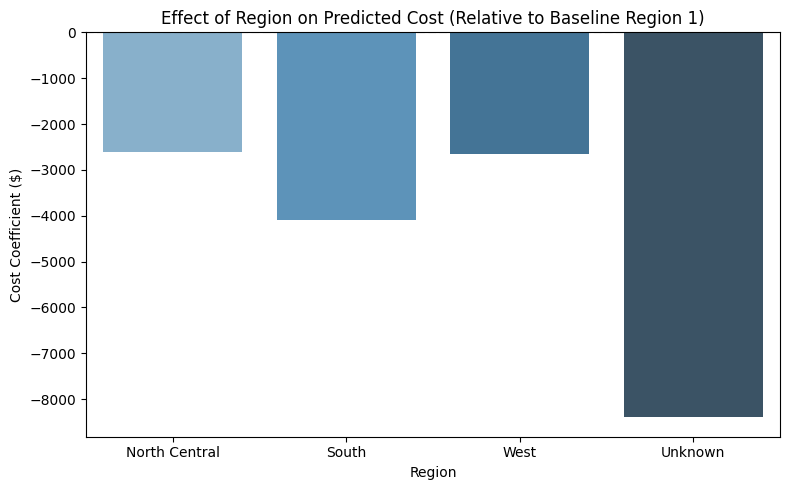

In [23]:
# Get the coefficients
coef_series = model.params.drop("const")  # drop intercept
coef_df = coef_series.reset_index()
coef_df.columns = ["Region_Dummy", "Coefficient"]

# Optional: Make prettier region labels
coef_df["Region"] = coef_df["Region_Dummy"].str.replace("REGION_", "")
region_mapping = {
    "2": "North Central",
    "3": "South",
    "4": "West",
    "5":"Unknown"
}
coef_df["Region_Label"] = coef_df["Region"].map(region_labels)
print(coef_df)
# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=coef_df, x="Region_Label", y="Coefficient", palette="Blues_d")
plt.title("Effect of Region on Predicted Cost (Relative to Baseline Region 1)")
plt.ylabel("Cost Coefficient ($)")
plt.xlabel("Region")
plt.axhline(0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()


In [49]:
# after you’ve run your OLS and have cost_predicted & cost_residual in your df…
# cost_residual = cost − cost_predicted

# 1) Build an “adjusted_cost” that adds back the overall intercept (so that the adjusted numbers
#    live on a realistic dollar scale rather than centering at zero).
global_intercept = model.params["const"]
print(global_intercept)
df_adj = df_encoded.copy()
df_adj["cost_adjusted"] = df_adj["cost_residual"] + global_intercept

display(df_adj.head())

23068.896114394593


,ENROLID,YEAR,EGEOLOC,cost,region_name,REGION_2,REGION_3,REGION_4,REGION_5,cost_residual,cost_predicted,cost_adjusted
0,166103,2017,18,4216.18,North Central,True,False,False,False,-16234.304415,20450.484415,6834.591699
1,166103,2018,18,1791.91,North Central,True,False,False,False,-18658.574415,20450.484415,4410.321699
2,166103,2019,18,4663.99,North Central,True,False,False,False,-15786.494415,20450.484415,7282.401699
3,2452303,2017,18,1845.28,North Central,True,False,False,False,-18605.204415,20450.484415,4463.691699
4,2452303,2018,18,1021.65,North Central,True,False,False,False,-19428.834415,20450.484415,3640.061699


In [72]:
# build your coef dict as before
coef_dict = dict(zip(coef_df['Region_Label'], coef_df['Coefficient']))
display(df_adj.head())
# map (reference region will come back NaN)
df_adj['region_coef'] = df_adj['region_name'].map(coef_dict)

# fill the NaNs with 0 for your reference region
df_adj['region_coef'] = df_adj['region_coef'].fillna(0)

# subtract off intercept + region effect if you like
intercept = model.params['const']
df_adj['cost_adjusted'] = df_adj['cost'] - df_adj['region_coef']
display(df_adj.head(10))


,ENROLID,YEAR,EGEOLOC,cost,region_name,REGION_2,REGION_3,REGION_4,REGION_5,cost_residual,cost_predicted,CKD_STAGE,region_coef,cost_adjusted
0,166103,2017,18,4216.18,North Central,True,False,False,False,-16234.304415,20450.484415,NaN,-2618.411699,6834.591699
1,166103,2018,18,1791.91,North Central,True,False,False,False,-18658.574415,20450.484415,NaN,-2618.411699,4410.321699
2,166103,2019,18,4663.99,North Central,True,False,False,False,-15786.494415,20450.484415,NaN,-2618.411699,7282.401699
3,2452303,2017,18,1845.28,North Central,True,False,False,False,-18605.204415,20450.484415,NaN,-2618.411699,4463.691699
4,2452303,2018,18,1021.65,North Central,True,False,False,False,-19428.834415,20450.484415,NaN,-2618.411699,3640.061699


,ENROLID,YEAR,EGEOLOC,cost,region_name,REGION_2,REGION_3,REGION_4,REGION_5,cost_residual,cost_predicted,CKD_STAGE,region_coef,cost_adjusted
0,166103,2017,18,4216.18,North Central,True,False,False,False,-16234.304415,20450.484415,NaN,-2618.411699,6834.591699
1,166103,2018,18,1791.91,North Central,True,False,False,False,-18658.574415,20450.484415,NaN,-2618.411699,4410.321699
2,166103,2019,18,4663.99,North Central,True,False,False,False,-15786.494415,20450.484415,NaN,-2618.411699,7282.401699
3,2452303,2017,18,1845.28,North Central,True,False,False,False,-18605.204415,20450.484415,NaN,-2618.411699,4463.691699
4,2452303,2018,18,1021.65,North Central,True,False,False,False,-19428.834415,20450.484415,NaN,-2618.411699,3640.061699
5,2452303,2019,18,2219.38,North Central,True,False,False,False,-18231.104415,20450.484415,CKD Stage 2,-2618.411699,4837.791699
6,26985801,2017,61,5690.11,West,False,False,True,False,-14723.685081,20413.795081,NaN,-2655.101033,8345.211033
7,26985801,2018,61,10976.10,West,False,False,True,False,-9437.695081,20413.795081,NaN,-2655.101033,13631.201033
8,26985801,2019,61,20620.71,West,False,False,True,False,206.914919,20413.795081,NaN,-2655.101033,23275.811033
9,27003301,2017,05,26759.39,Northeast,False,False,False,False,3690.493886,23068.896114,NaN,0.000000,26759.390000


## Region-level statistic

In [7]:
region_map_expr = F.create_map([x for kv in region_labels.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])
df_cost_demo = (
            df_cost_demo
            .withColumn("Region_Label", region_map_expr.getItem(F.col("REGION").cast("string")))
            .fillna({ "Region_Label": "Unknown"}) #"Location": "Unmapped",
        )
df_cost_demo_pd = df_cost_demo.toPandas()

region_stats = (
    df_cost_demo_pd.groupby(["Region_Label","YEAR"])
    .agg(
        mean_cost=('cost', 'mean'),
        median_cost=('cost', 'median'),
        std_cost=('cost', 'std'),
        skew_cost=('cost', lambda x: x.skew()),
        n_enrollees=('cost', 'count')
    )
    .reset_index()
)



ENROLID         788981
Region_Label    788981
annual_cost     788981
dtype: int64


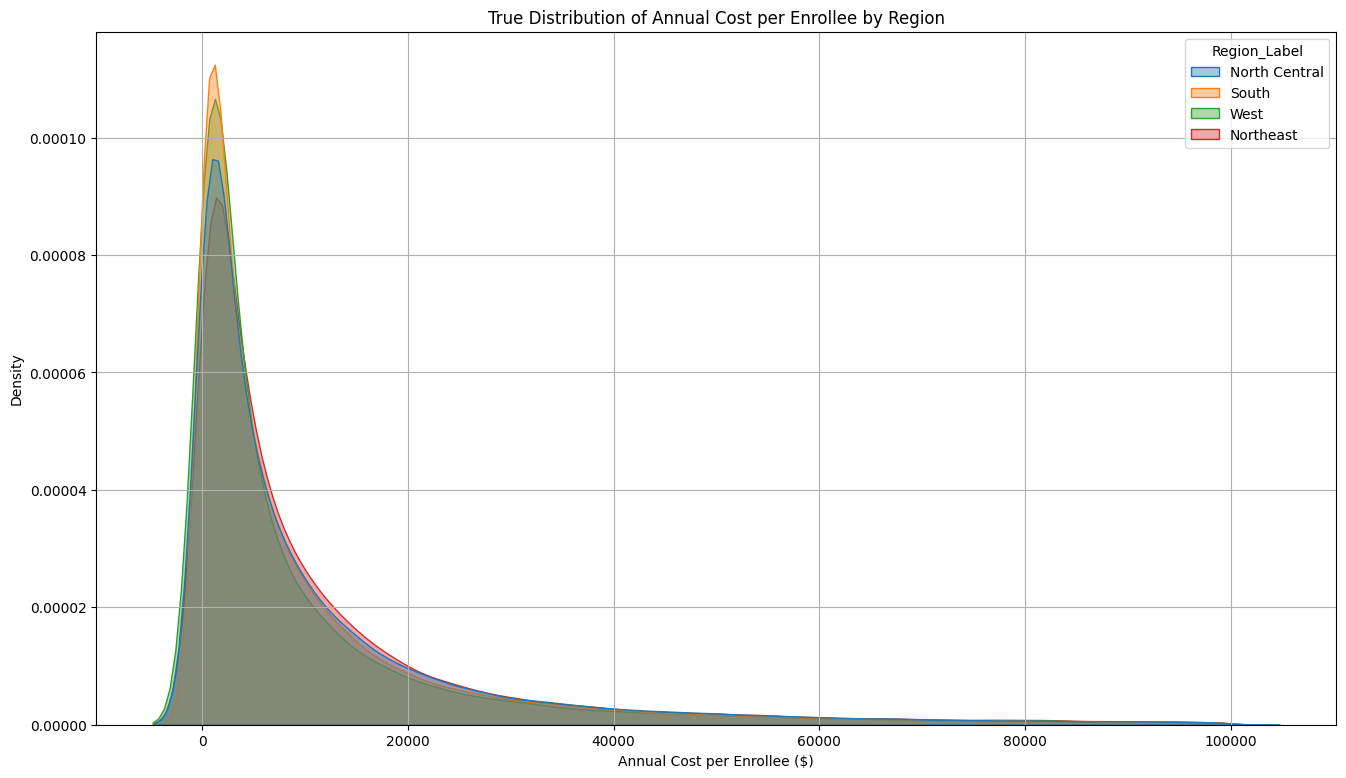

In [20]:
# 1) Filter
df_filtered = df_cost_demo_pd.query("cost < 100000 and YEAR == 2017 and Region_Label != 'Unknown'")

# 2) Aggregate to annual cost per enrollee
df_enrollee = (
    df_filtered
    .groupby(['ENROLID', 'Region_Label'], as_index=False)
    .agg({'cost': 'sum'})
    .rename(columns={'cost': 'annual_cost'})
)
print(df_enrollee.count())
# 3) Plot KDEs of annual cost by region
plt.figure(figsize=(16, 9))
sns.kdeplot(
    data=df_enrollee,
    x="annual_cost",
    hue="Region_Label",
    common_norm=False,
    fill=True,
    alpha=0.4
)

plt.title("True Distribution of Annual Cost per Enrollee by Region")
plt.xlabel("Annual Cost per Enrollee ($)")
plt.ylabel("Density")
plt.grid(True)
plt.show()


KDE Peak Annual Costs by Region:
  North Central  : $761
  Northeast      : $921
  South          : $641
  Unknown        : $1,241
  West           : $761


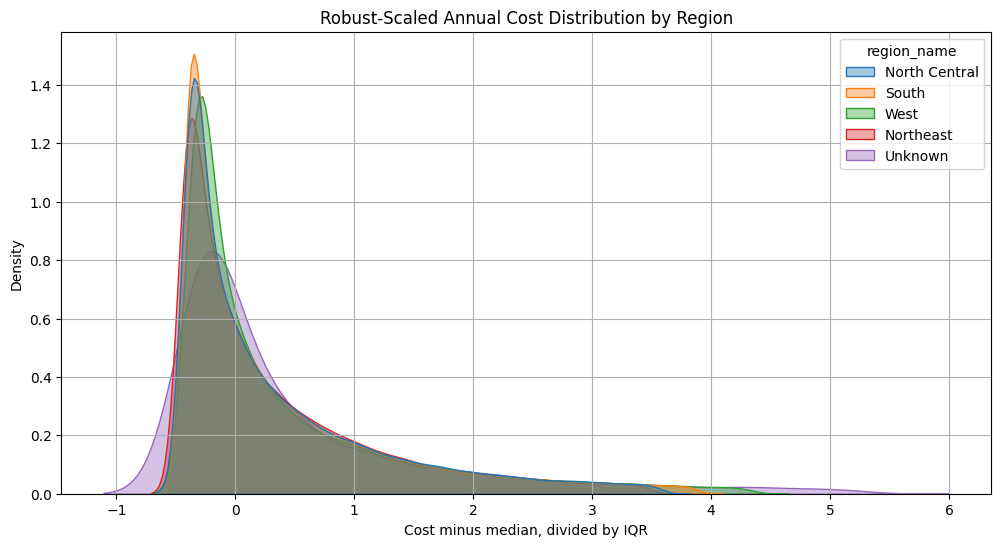

In [60]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Filter & aggregate to annual cost per enrollee
df_filtered = df_cost_demo_pd.query("cost < 40000 and YEAR == 2017")
df_enrollee = (
    df_filtered
    .groupby(['ENROLID', 'region_name'], as_index=False)
    .agg({'cost': 'sum'})
    .rename(columns={'cost': 'annual_cost'})
)

# 2) Find KDE peak for each region
peaks = {}
x_grid = np.linspace(df_enrollee['annual_cost'].min(),
                     df_enrollee['annual_cost'].max(), 1000)

for region, grp in df_enrollee.groupby('region_name'):
    kde = gaussian_kde(grp['annual_cost'])
    dens = kde(x_grid)
    peaks[region] = x_grid[np.argmax(dens)]

print("KDE Peak Annual Costs by Region:")
for region, peak in peaks.items():
    print(f"  {region:15s}: ${peak:,.0f}")

# 3) Robust scaling: (cost – median) / IQR
medians = df_enrollee.groupby('region_name')['annual_cost'].median()
iqrs    = df_enrollee.groupby('region_name')['annual_cost'] \
          .apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

df_enrollee['robust_scaled'] = df_enrollee.apply(
    lambda r: (r['annual_cost'] - medians[r['region_name']]) / iqrs[r['region_name']],
    axis=1
)

# 4) Plot the scaled distributions
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=df_enrollee,
    x="robust_scaled",
    hue="region_name",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.title("Robust-Scaled Annual Cost Distribution by Region")
plt.xlabel("Cost minus median, divided by IQR")
plt.ylabel("Density")
plt.grid(True)
plt.show()


In [28]:
import plotly.express as px

fig = px.histogram(
    df_cost_demo_pd.query("cost < 95000 and YEAR == 2017 and Region_Label == 'Northeast'"),
    x="cost",
    nbins=50,
    title="Distribution of 2017 Enrollee Cost in Northeast (< $100k)",
    labels={"cost": "Cost ($)"}
)
fig.update_layout(yaxis_title="Number of Enrollees")
fig.show()

In [ ]:
# Filter to NE region, 2017, and costs < 100k
df_ne = df_cost_demo_pd.query("cost < 100000 and YEAR == 2017 and Region_Label == 'Northeast'")
# Total enrollees in this slice
total_ne = len(df_ne)
print(total_ne)

# Define your cutoffs
cutoffs = [1500,5000,15000,20000,30000, 40_000, 50_000, 60_000, 70_000, 80_000,90_000,100_000]

# Build the table
rows = []
for cutoff in cutoffs:
    count = (df_ne["cost"] >= cutoff).sum()
    pct   = count / total_ne * 100
    rows.append({
        "Cost_Cutoff":    cutoff,
        "Enrollees_≤Cutoff": count,
        "% of NE Cohort": f"{pct:.1f}%"
    })

df_cutoff_stats = pd.DataFrame(rows)

# Show it
print(df_cutoff_stats.to_string(index=False))


133207
 Cost_Cutoff  Enrollees_≤Cutoff % of NE Cohort
        1500              32306          24.3%
        5000              64743          48.6%
       15000             101815          76.4%
       20000             110304          82.8%
       30000             119312          89.6%
       40000             124061          93.1%
       50000             126990          95.3%
       60000             129074          96.9%
       70000             130482          98.0%
       80000             131611          98.8%
       90000             132529          99.5%
      100000             133207         100.0%


/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_24009/1714188439.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




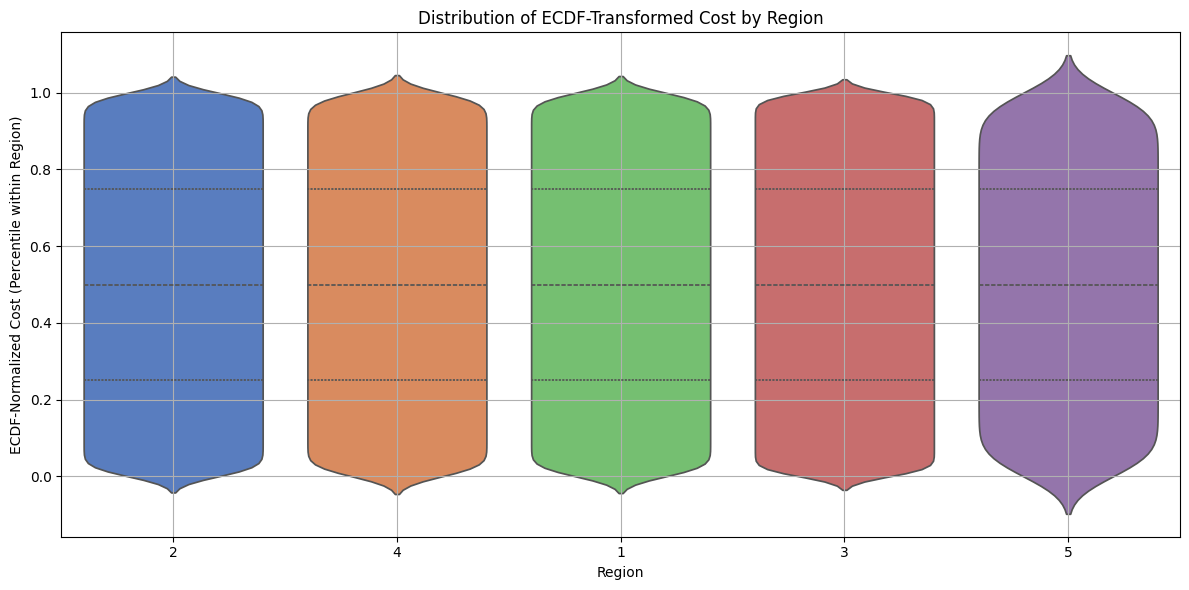

In [83]:
from scipy.stats import rankdata
def compute_ecdf(series):
    ranks = rankdata(series, method='average')
    return ranks / len(series)

df_cost_demo_pd["cost_ecdf"] = (
    df_cost_demo_pd.groupby("REGION")["cost"]
    .transform(compute_ecdf)
)

# Plot ECDF-transformed cost distribution by region
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_cost_demo_pd,
    x="REGION",
    y="cost_ecdf",
    inner="quartile",
    palette="muted"
)
plt.title("Distribution of ECDF-Transformed Cost by Region")
plt.ylabel("ECDF-Normalized Cost (Percentile within Region)")
plt.xlabel("Region")
plt.grid(True)
plt.tight_layout()
plt.show()

In [84]:
df_cost_demo_pd.head()

,ENROLID,YEAR,REGION,EGEOLOC,cost,region_name,cost_ecdf
0,148101,2017,2,18,25637.43,North Central,0.824043
1,148101,2018,2,18,705.57,North Central,0.152968
2,148101,2019,2,18,897.12,North Central,0.179947
3,371401,2017,2,18,5754.30,North Central,0.488957
4,371401,2018,2,18,7182.21,North Central,0.539955
